# LSTM Model

## Packages

In [1]:
import numpy as np
import pandas as pd
from lstm_functions import *

from tensorflow.keras.models import Sequential
from tensorflow.keras import layers, callbacks
from tensorflow.keras.optimizers import Adam

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
from scipy import stats

## Reading and transforming the data

In [2]:
df = pd.read_csv('full_dataset_20250830.csv')
df.head(10)

,Unnamed: 0,Date,eur_close,MNB,ECB,mean_kinfo,mean_matolcsy,mean_nagy,mean_varga,max_kinfo,max_matolcsy,max_nagy,max_varga,eurczk,eurpln,eurron,cetop,FED,BUX
0,1,2018-05-31,319.404,0.009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.814899,4.31416,4.6511,1948.804381,0.0175,35356.826181
1,2,2018-06-03,319.766,0.009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.797701,4.30005,4.6574,1948.804381,0.0175,35356.826181
2,3,2018-06-04,318.491,0.009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.696800,4.27064,4.6516,2017.378964,0.0175,37194.372093
3,4,2018-06-05,318.665,0.009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.609900,4.27900,4.6462,2030.569735,0.0175,36677.560541
4,5,2018-06-06,317.931,0.009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.658800,4.26760,4.6487,2040.194920,0.0175,37157.463596
5,6,2018-06-07,318.367,0.009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.757200,4.27630,4.6531,2054.548958,0.0175,37401.246283
6,7,2018-06-10,319.412,0.009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.732201,4.27632,4.6584,2054.548958,0.0175,37401.246283
7,8,2018-06-11,320.972,0.009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.618900,4.26362,4.6578,2024.502757,0.0175,36606.383877
8,9,2018-06-12,319.474,0.009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.670000,4.27992,4.6544,2029.550646,0.0175,36348.106149
9,10,2018-06-13,320.226,0.009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.704201,4.27570,4.6594,2018.610074,0.0200,35868.588914


In [3]:
df.index = pd.to_datetime(df['Date'])
df_eur = df[['eur_close', 'FED', 'MNB', 'ECB', 'BUX', 'cetop', 'mean_matolcsy', 'mean_varga', 'mean_nagy', 'mean_kinfo', 'eurczk', 'eurpln', 'eurron']]
df_eur

,eur_close,FED,MNB,ECB,BUX,cetop,mean_matolcsy,mean_varga,mean_nagy,mean_kinfo,eurczk,eurpln,eurron
Date,,,,,,,,,,,,,
2018-05-31,319.404,0.0175,0.009,0.000,35356.826181,1948.804381,0.0,0.0,0.000000,0.0,25.814899,4.31416,4.65110
2018-06-03,319.766,0.0175,0.009,0.000,35356.826181,1948.804381,0.0,0.0,0.000000,0.0,25.797701,4.30005,4.65740
2018-06-04,318.491,0.0175,0.009,0.000,37194.372093,2017.378964,0.0,0.0,0.000000,0.0,25.696800,4.27064,4.65160
2018-06-05,318.665,0.0175,0.009,0.000,36677.560541,2030.569735,0.0,0.0,0.000000,0.0,25.609900,4.27900,4.64620
2018-06-06,317.931,0.0175,0.009,0.000,37157.463596,2040.194920,0.0,0.0,0.000000,0.0,25.658800,4.26760,4.64870
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-10,403.845,0.0450,0.065,0.029,87600.751143,2960.215276,0.0,0.0,-0.103065,0.0,25.075899,4.18839,4.97607
2025-02-11,403.584,0.0450,0.065,0.029,87713.729947,2983.598294,0.0,0.0,0.000000,0.0,25.066500,4.18080,4.96400
2025-02-12,402.856,0.0450,0.065,0.029,88050.195162,3010.970973,0.0,0.0,0.000000,0.0,25.087200,4.17079,4.97624


## EUR model with external variables

<Axes: xlabel='Date'>

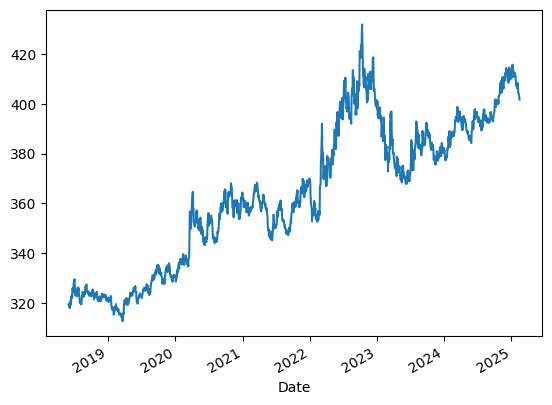

In [4]:
df_eur['eur_close'].plot()

In [5]:
windowed_df = df_to_windowed_df(df_eur['eur_close'], '2018-06-04', '2025-02-14', 2)
dates, X, y = windowed_df_to_date_X_y(windowed_df)
# X = merge_with_dummies(X, df_eur[['Fed', 'MNB', 'ECB', 'mean_matolcsy', 'mean_varga', 'mean_nagy', 'mean_kinfo']], dates)
# X = merge_with_dummies(X, df_eur_std[['FED', 'MNB', 'ECB', 'BUX', 'cetop', 'mean_matolcsy', 'mean_varga', 'mean_nagy', 'mean_kinfo', 'eurczk', 'eurpln', 'eurron']], dates)
X = merge_with_dummies(X, df_eur[['FED', 'MNB', 'ECB', 'BUX', 'cetop']], dates)

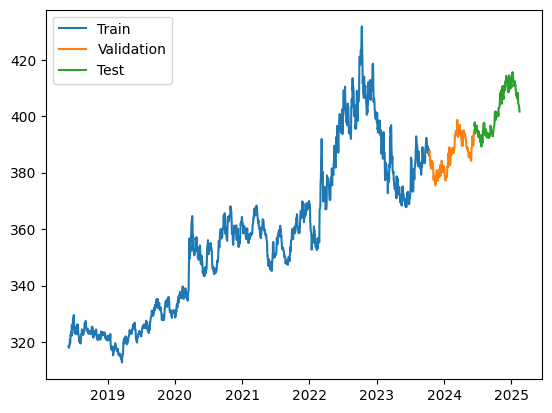

In [6]:
q_80 = int(len(dates) * .8)
q_90 = int(len(dates) * .9)

dates_train, X_train, y_train = dates[:q_80], X[:q_80], y[:q_80]

dates_val, X_val, y_val = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90]
dates_test, X_test, y_test = dates[q_90:], X[q_90:], y[q_90:]

plt.plot(dates_train, y_train)
plt.plot(dates_val, y_val)
plt.plot(dates_test, y_test)

plt.legend(['Train', 'Validation', 'Test'])

### Model

In [7]:
model = Sequential([layers.Input((len(X[1]), 1)),
                    layers.LSTM(32),
                    layers.Dense(8, activation='relu'),
                    layers.Dense(8, activation='relu'),
                    layers.Dense(8, activation='relu'),
                    layers.Dense(8, activation='relu'),
                    layers.Dense(1)])

model.compile(loss='mse', 
              optimizer='adam',
              metrics=['mean_absolute_error'])

lstm = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=250, callbacks = callbacks.EarlyStopping(patience = 25, monitor = 'val_loss'))

Epoch 1/250
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 127252.1562 - mean_absolute_error: 355.6838 - val_loss: 148731.5000 - val_mean_absolute_error: 385.6139
Epoch 2/250
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 126875.4844 - mean_absolute_error: 355.1715 - val_loss: 147236.3906 - val_mean_absolute_error: 383.6704
Epoch 3/250
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 124305.5234 - mean_absolute_error: 351.5005 - val_loss: 139676.6875 - val_mean_absolute_error: 373.6888
Epoch 4/250
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 113703.4531 - mean_absolute_error: 336.0779 - val_loss: 112770.6094 - val_mean_absolute_error: 335.7636
Epoch 5/250
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 83065.7656 - mean_absolute_error: 286.1688 - val_loss: 55437.4336 - val_mean_absolute_error: 235.3806
Epoch 6/250
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 29553.9707 - mean_absolute_error: 165.5298 - val_loss: 5913.1904 - val_mean_absolute_error: 76.6798
Epoch 7/250
44/44 ━━━━━━━━━━

Training and validation loss

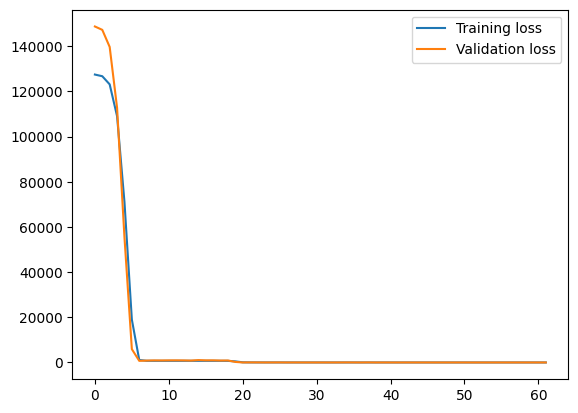

In [8]:
plt.plot(lstm.history['loss'], label = 'Training loss')
plt.plot(lstm.history['val_loss'], label = 'Validation loss')
plt.legend(['Training loss', 'Validation loss'])

Train predictions

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


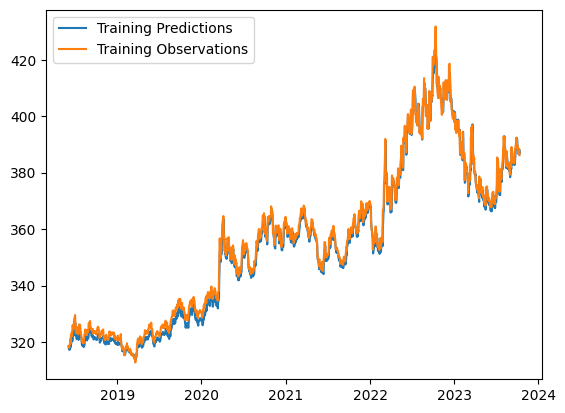

In [9]:
train_predictions = model.predict(X_train).flatten()

plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.legend(['Training Predictions', 'Training Observations'])

Validation predictions 

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


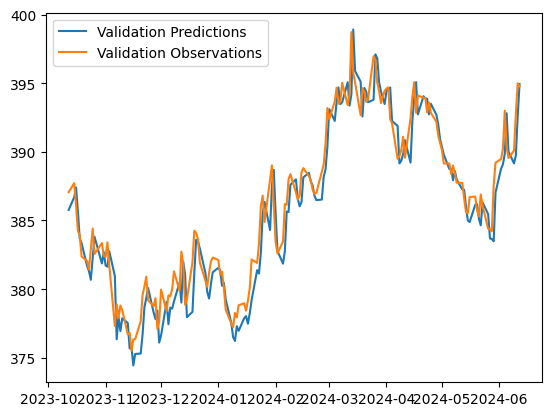

In [10]:
val_predictions = model.predict(X_val).flatten()

plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.legend(['Validation Predictions', 'Validation Observations'])

Test predictions

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


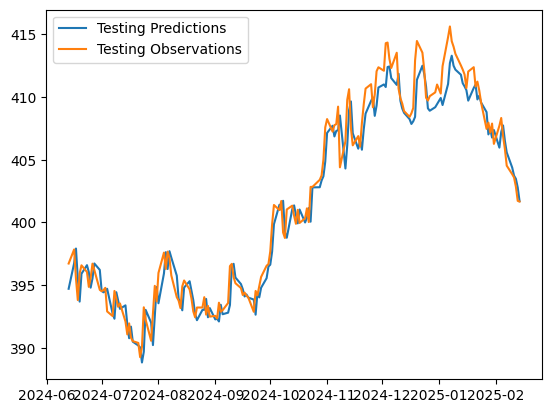

In [11]:
test_predictions = model.predict(X_test).flatten()

plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(['Testing Predictions', 'Testing Observations'])

Predictions combined

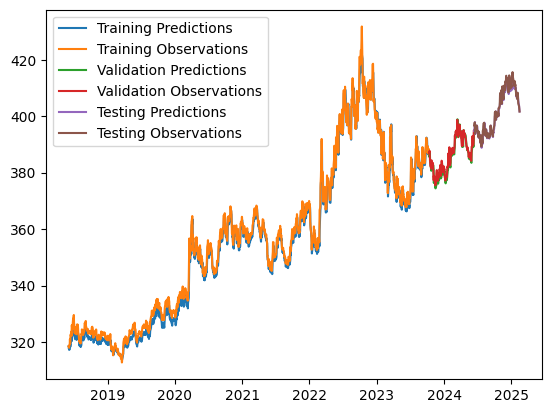

In [12]:
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(['Training Predictions', 
            'Training Observations',
            'Validation Predictions', 
            'Validation Observations',
            'Testing Predictions', 
            'Testing Observations'])

Metrics

In [13]:
mae = mean_absolute_error(y_test, test_predictions)
rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

print(f'Mean Absolute Error on test data: {mae}')
print(f'Root Mean Squared Error on test data: {rmse}')

Mean Absolute Error on test data: 1.1545038223266602
Root Mean Squared Error on test data: 1.4598089745066547


### Ceteris paribus analysis

In [14]:
results = []

variable_names = ['Y_-2','Y_-1','FED', 'MNB', 'ECB', 'BUX', 'cetop']  

for var_idx, var_name in enumerate(variable_names):
    for pct_change in np.arange(-0.10, 0.11, 0.01):
        # Copy X_test to avoid modifying the original
        X_mod = np.copy(X_test)
        # Apply percentage change to the selected variable
        X_mod[:, var_idx, 0] *= (1 + pct_change)
        # Predict with the modified input
        preds = model.predict(X_mod).flatten()
        # Store results for each sample
        for i, pred in enumerate(preds):
            results.append({
                'variable': var_name,
                'sample_idx': i,
                'pct_change': pct_change,
                'prediction': pred
            })

# Convert results to DataFrame
df_ceteris_paribus = pd.DataFrame(results)
df_ceteris_paribus.to_csv('ceteris_paribus_results.csv', index=False)
df_ceteris_paribus

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 

,variable,sample_idx,pct_change,prediction
0,Y_-2,0,-0.1,394.345917
1,Y_-2,1,-0.1,396.378906
2,Y_-2,2,-0.1,397.561157
3,Y_-2,3,-0.1,395.156342
4,Y_-2,4,-0.1,393.328613
...,...,...,...,...
25720,cetop,170,0.1,404.374329
25721,cetop,171,0.1,403.729828
25722,cetop,172,0.1,403.481262
25723,cetop,173,0.1,402.790100


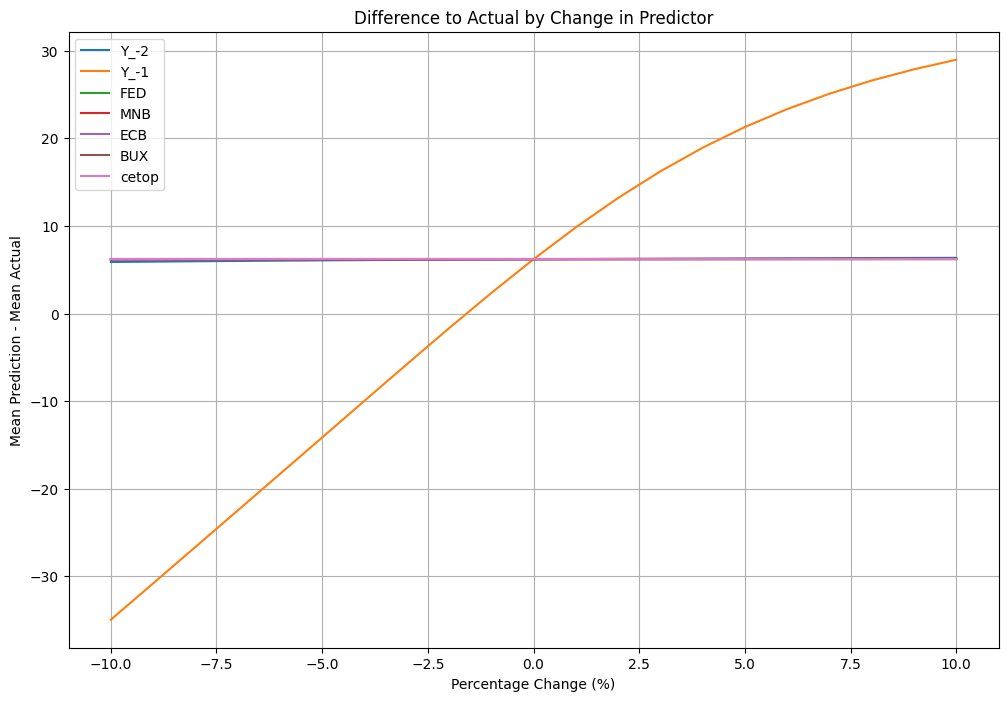

In [15]:
# Plot difference to actual prediction by change in predictor
plt.figure(figsize=(12, 8))
for var in df_ceteris_paribus['variable'].unique():
    subset = df_ceteris_paribus[df_ceteris_paribus['variable'] == var]
    # Aggregate predictions by pct_change (mean over samples)
    mean_preds = subset.groupby('pct_change')['prediction'].mean()
    # Calculate difference to actual
    # Use the mean of y_test for reference (or median, or sample-wise if needed)
    actual = y_test[:len(mean_preds)]
    diff = mean_preds.values - np.mean(actual)
    plt.plot(mean_preds.index * 100, diff, label=var)

plt.xlabel('Percentage Change (%)')
plt.ylabel('Mean Prediction - Mean Actual')
plt.title('Difference to Actual by Change in Predictor')
plt.legend()
plt.grid(True)
plt.show()

c:\Users\dittr\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\dittr\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


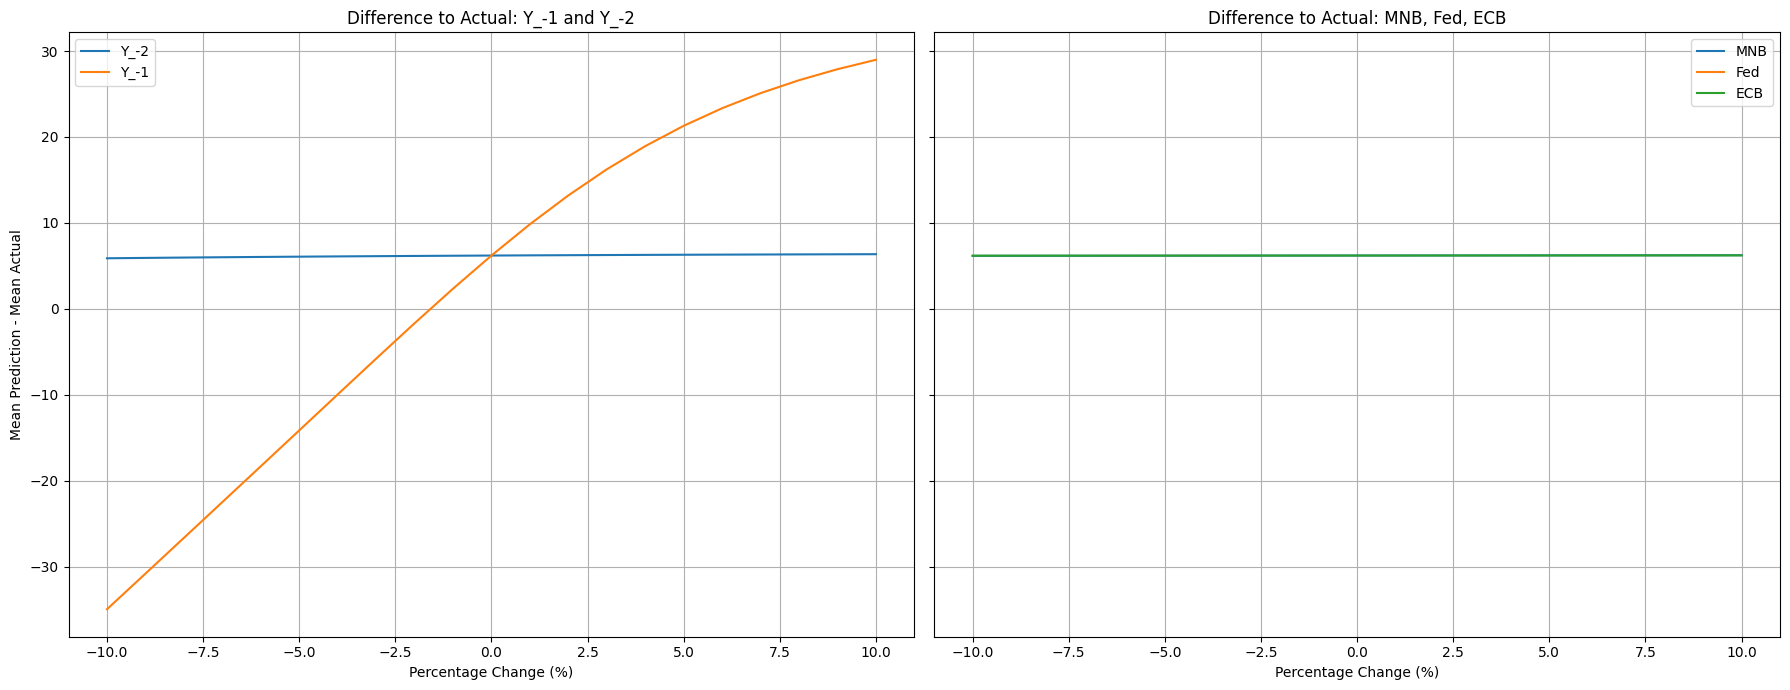

In [16]:
# Plot two subplots: one for Y_-1 and Y_-2, one for MNB, Fed, ECB
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# First subplot: Y_-1 and Y_-2
for var in ['Y_-2', 'Y_-1']:
    subset = df_ceteris_paribus[df_ceteris_paribus['variable'] == var]
    mean_preds = subset.groupby('pct_change')['prediction'].mean()
    actual = y_test[:len(mean_preds)]
    diff = mean_preds.values - np.mean(actual)
    axes[0].plot(mean_preds.index * 100, diff, label=var)
axes[0].set_title('Difference to Actual: Y_-1 and Y_-2')
axes[0].set_xlabel('Percentage Change (%)')
axes[0].set_ylabel('Mean Prediction - Mean Actual')
axes[0].legend()
axes[0].grid(True)

# Second subplot: MNB, Fed, ECB
for var in ['MNB', 'Fed', 'ECB']:
    subset = df_ceteris_paribus[df_ceteris_paribus['variable'] == var]
    mean_preds = subset.groupby('pct_change')['prediction'].mean()
    actual = y_test[:len(mean_preds)]
    diff = mean_preds.values - np.mean(actual)
    axes[1].plot(mean_preds.index * 100, diff, label=var)
axes[1].set_title('Difference to Actual: MNB, Fed, ECB')
axes[1].set_xlabel('Percentage Change (%)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### XAI

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


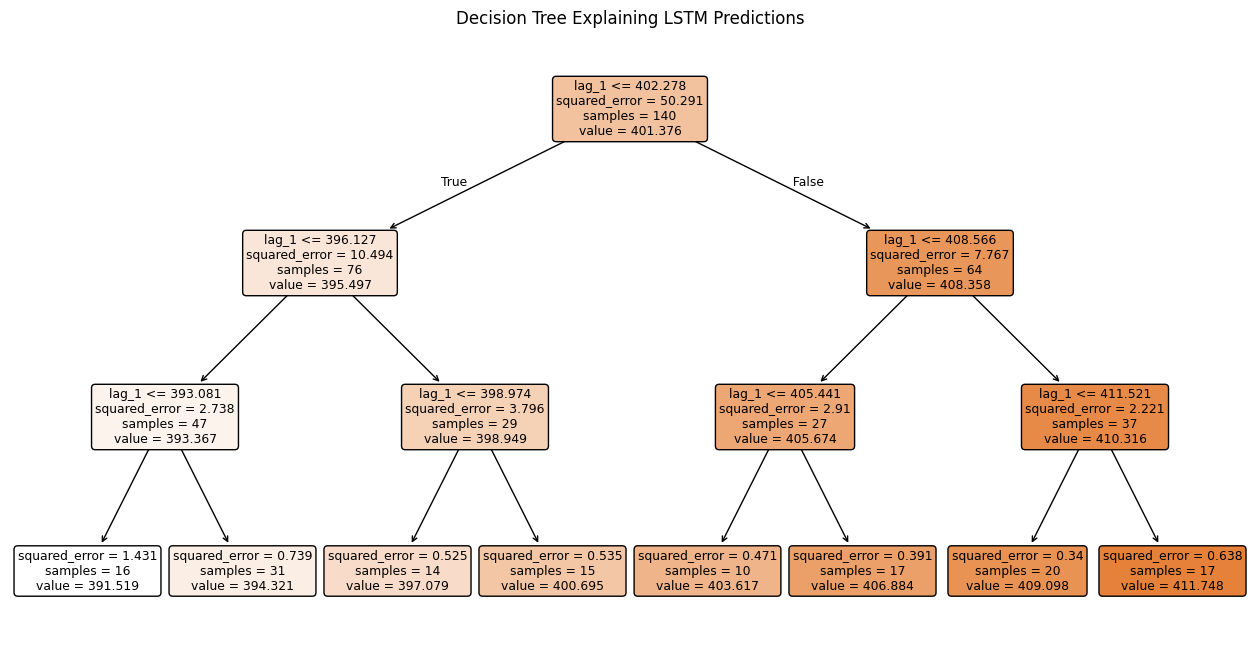

In [17]:
# Decision tree to explain LSTM predictions (XAI)
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split

# Prepare predictors and target for the decision tree
# Flatten X_test to shape (samples, features)
X_flat = X_test.reshape(X_test.shape[0], X_test.shape[1])
# Target is the LSTM's prediction
y_lstm_pred = model.predict(X_test).flatten()

# Split for visualization (optional)
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X_flat, y_lstm_pred, test_size=0.2, random_state=42)

# Fit decision tree
dt = DecisionTreeRegressor(max_depth=3, random_state=42)
dt.fit(X_train_dt, y_train_dt)

# Plot the tree
plt.figure(figsize=(16, 8))
plot_tree(dt, feature_names=[f'lag_{i}' for i in range(X_flat.shape[1])], filled=True, rounded=True)
plt.title('Decision Tree Explaining LSTM Predictions')
plt.show()

Variable importance with Random Forest

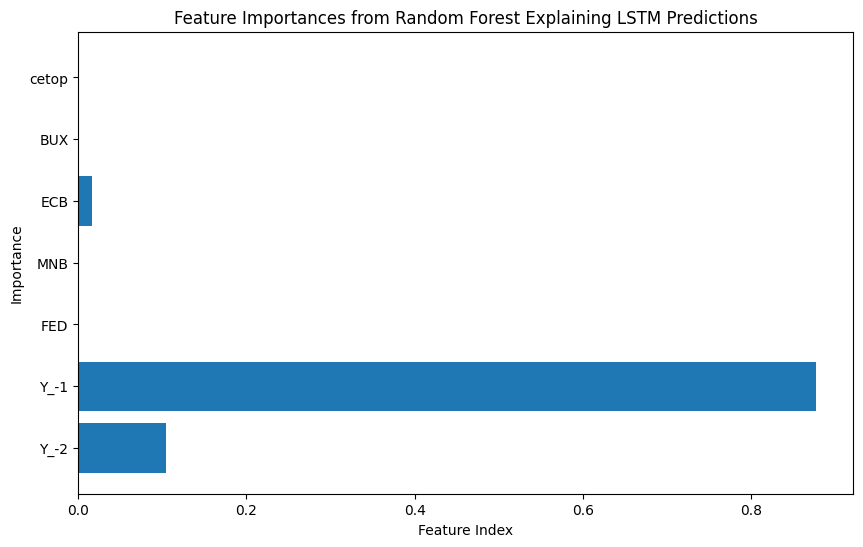

In [18]:
random_forest = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_flat, y_lstm_pred)
importances = random_forest.feature_importances_

plt.figure(figsize=(10, 6))
plt.barh(variable_names, importances)
plt.xlabel('Feature Index')
plt.ylabel('Importance')
plt.title('Feature Importances from Random Forest Explaining LSTM Predictions')
plt.show()

# EUR model simulations

Defining number of simualtions:

In [19]:
n_sim = 100

In [20]:
import time
start_time = time.time()

In [21]:
external_variable_names = ['eur_close', 'FED', 'MNB', 'ECB', 'BUX', 'cetop', 'eurczk', 'eurpln', 'eurron']

## Base model

In [22]:
rmse_all_variables, errors_all_variables = sim_lstm(df_eur, 'eur_close', external_variable_names + ['mean_matolcsy', 'mean_varga', 'mean_nagy', 'mean_kinfo'],  n_sim)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━

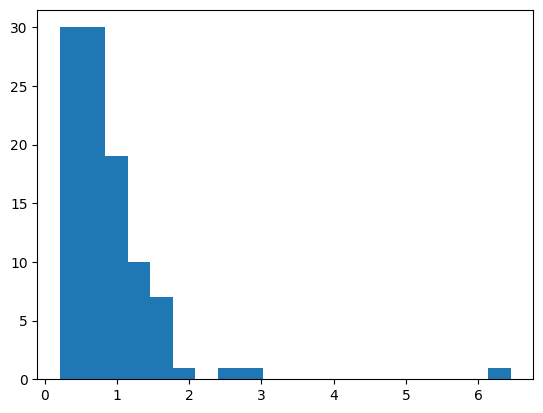

In [23]:
plt.hist(rmse_all_variables, bins = 20)
plt.show()

In [24]:
# stats.describe(rmse_all_variables)

## Models without all the variables

### No dummy model

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 

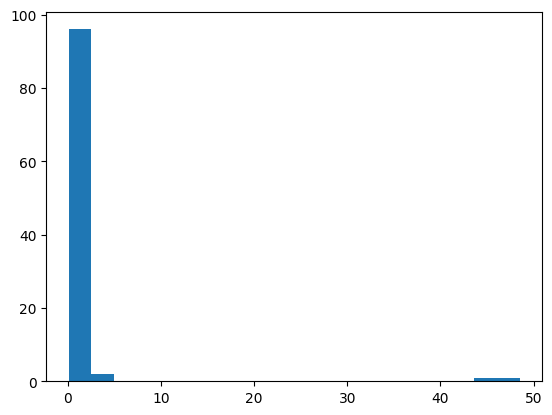

In [25]:
rmse_no_dummies, errors_no_dummies  = sim_lstm(df_eur, 'eur_close', external_variable_names,  n_sim)
plt.hist(rmse_no_dummies, bins = 20)
plt.show()
# stats.describe(mse_no_dummies)

### Only Kormanyinfo

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━

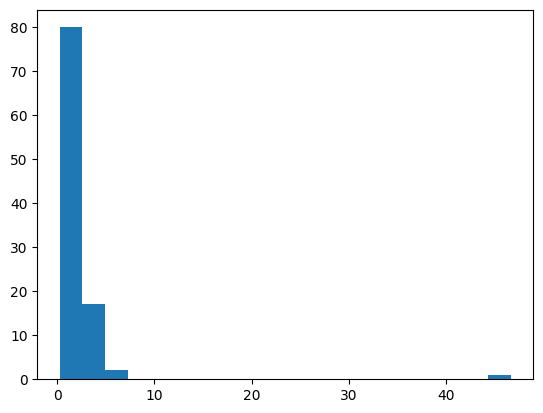

In [26]:
rmse_only_kinfo, errors_only_kinfo = sim_lstm(df_eur, 'eur_close', external_variable_names + ['mean_kinfo'],  n_sim)
plt.hist(rmse_only_kinfo, bins = 20)
plt.show()

### Only Varga Mihaly

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 

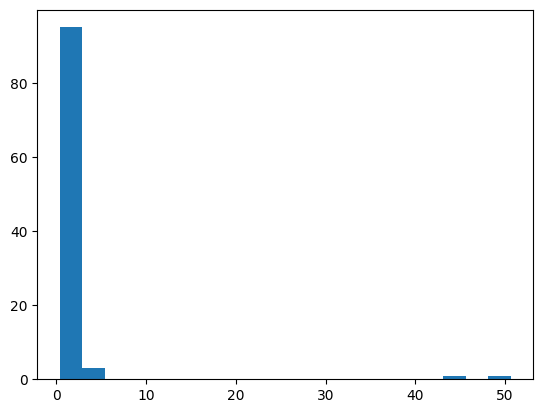

In [27]:
rmse_only_vm, errors_only_vm = sim_lstm(df_eur, 'eur_close', external_variable_names + ['mean_varga'],  n_sim)
plt.hist(rmse_only_vm, bins = 20)
plt.show()

### Only Nagy Marton

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 

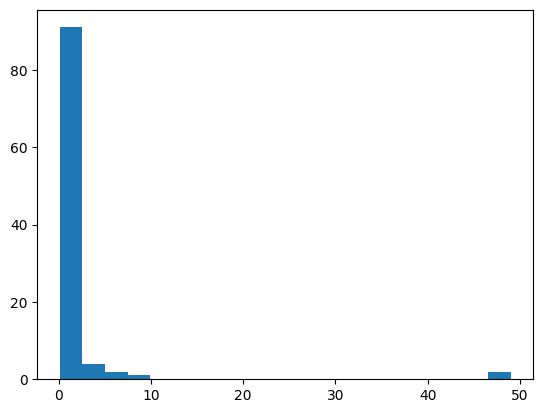

In [28]:
rmse_only_nm, errors_only_nm =sim_lstm(df_eur, 'eur_close', external_variable_names + ['mean_nagy'],  n_sim)
plt.hist(rmse_only_nm, bins = 20)
plt.show()

### Only Matolcsgy Gyorgy

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━

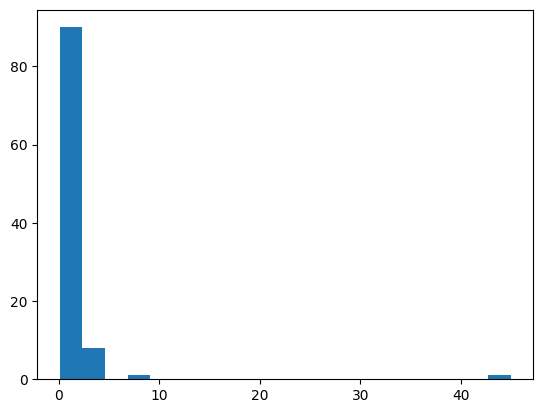

In [29]:
rmse_only_mgy, errors_only_mgy = sim_lstm(df_eur, 'eur_close', external_variable_names + ['mean_matolcsy'],  n_sim)
plt.hist(rmse_only_mgy, bins = 20)
plt.show()
# stats.describe(mse_only_mgy)

In [30]:
rmse_output = pd.DataFrame(
    {'rmse_all_variables': rmse_all_variables,
     'rmse_no_dummies': rmse_no_dummies,
     'rmse_only_kinfo': rmse_only_kinfo,
     'rmse_only_vm': rmse_only_vm,
     'rmse_only_nm': rmse_only_nm,
     'rmse_only_mgy': rmse_only_mgy
     }
)

rmse_output.to_excel('./rmse_results.xlsx')

with pd.ExcelWriter('errors_results.xlsx', engine='xlsxwriter') as writer:
    errors_all_variables.to_excel(writer, sheet_name = 'all_variables')
    errors_no_dummies.to_excel(writer, sheet_name = 'no_dummies')
    errors_only_kinfo.to_excel(writer, sheet_name = 'only_kinfo')
    errors_only_vm.to_excel(writer, sheet_name = 'only_vm')
    errors_only_nm.to_excel(writer, sheet_name = 'only_nm')
    errors_only_mgy.to_excel(writer, sheet_name = 'only_mgy')



print("--- %s minutes ---" % ((time.time() - start_time)/60))

--- 54.39436116218567 minutes ---
